<a href="https://colab.research.google.com/github/promeroec/mesa-abm/blob/main/notebooks/ddbanks2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mesa pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.9/239.9 kB 3.8 MB/s eta 0:00:00


In [2]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional
import random

print(f"Mesa version: {mesa.__version__}")

Mesa version: 3.3.1


In [3]:
class Customer(mesa.Agent):
    """A bank customer/depositor agent"""

    def __init__(self, model, bank_id):
        super().__init__(model)
        self.bank_id = bank_id
        self.deposit_t0 = 1.0  # Initial deposit
        self.withdraw1 = 0.0
        self.withdraw2 = 0.0
        self.account1 = 0.0
        self.account2 = 0.0
        self.fitness1 = 0.0
        self.fitness2 = 0.0
        self.active = True
        self.Rc = 1 + self.random.uniform(0, 0.5)  # Customer's subjective interest rate

        # Determine if impatient or patient
        self.dtype = "impatient" if self.random.random() < model.impatient_probability else "patient"

    def step(self):
        """Customer decision-making process"""
        if not self.active:
            return

        # Get my bank
        bank = self.model.banks[self.bank_id]
        if not bank.active:
            self.active = False
            return

        # Make withdrawal decision
        self.make_decision(bank)

    def make_decision(self, bank):
        """Decide whether to withdraw based on type and conditions"""
        consume1 = 1 + self.random.uniform(0, 0.2)

        # Calculate fraction served
        fj = bank.n_served / bank.num_customers if bank.num_customers > 0 else 0

        # Count impatient customers in the bank
        bank_customers = [c for c in self.model.customers if c.bank_id == self.bank_id]
        n_impatient_in_bank = sum(1 for c in bank_customers if c.dtype == "impatient")
        expected_impatient_fraction = n_impatient_in_bank / len(bank_customers) if len(bank_customers) > 0 else self.model.impatient_probability

        if self.dtype == "impatient":
            # Impatient agents always try to withdraw
            if fj > expected_impatient_fraction:
                self.fitness1 = 1
                self.withdraw1 = self.fitness1
            else:
                self.fitness1 = consume1
                self.withdraw1 = self.fitness1
            self.fitness2 = 0
            self.withdraw2 = 0
        else:
            # Patient agents decide based on queue size and interest rates
            if fj > expected_impatient_fraction and self.Rc > bank.Rb:
                # Run condition - withdraw early
                self.fitness1 = consume1
                self.withdraw1 = self.fitness1
                self.fitness2 = 0
                self.withdraw2 = 0
            else:
                # Wait for higher return
                if bank.n_served > 1:
                    self.fitness2 = (bank.Rb * (1 - (consume1 * bank.n_served))) / (1 - bank.n_served)
                else:
                    self.fitness2 = bank.Rb
                self.withdraw2 = self.fitness2
                self.fitness1 = 0
                self.withdraw1 = 0

        # Update account balances
        self.fitness_check()

    def fitness_check(self):
        """Update account balances after withdrawal decision"""
        if self.dtype == "impatient":
            self.account1 = self.deposit_t0 - self.withdraw1 - self.withdraw2
            self.deposit_t0 = max(0, self.deposit_t0 - self.withdraw1 - self.withdraw2)
            self.account2 = self.deposit_t0
        else:
            self.account2 = self.deposit_t0 - self.withdraw2 - self.withdraw1
            self.deposit_t0 = max(0, self.deposit_t0 - self.withdraw2 - self.withdraw1)
            self.account1 = self.deposit_t0

        # Deactivate if account is depleted
        if self.deposit_t0 <= 0:
            self.active = False

print("✓ Customer agent defined")

✓ Customer agent defined


In [4]:
class Bank(mesa.Agent):
    """A bank agent"""

    def __init__(self, model, num_customers):
        super().__init__(model)
        self.num_customers = num_customers
        self.init_deposits = float(num_customers)  # Each customer deposits 1
        self.fin_balance = self.init_deposits
        self.n_served = 0
        self.loans = 0.0
        self.lender_id = None
        self.active = True
        self.Rb = 1 + self.random.uniform(0, 0.5)  # Bank's interest rate
        self.failed = False

    def step(self):
        """Bank operations - serving customers and managing balance"""
        if not self.active:
            return

        # Update interest rate
        self.Rb = 1 + self.random.uniform(0, 0.5)

        # Calculate total withdrawals from customers
        my_customers = [c for c in self.model.customers if c.bank_id == self.unique_id]
        tot_withdrawals = sum(c.withdraw1 + c.withdraw2 for c in my_customers)

        # Count number of customers who withdrew
        self.n_served = sum(1 for c in my_customers if (c.withdraw1 > 0 or c.withdraw2 > 0))

        # Determine if bank should invest
        n_withdraw1 = sum(1 for c in my_customers if c.withdraw1 > 0)
        expected_impatient = len(my_customers) * self.model.impatient_probability

        if n_withdraw1 <= expected_impatient:
            invest = (self.init_deposits - tot_withdrawals) * self.Rb
        else:
            invest = 0

        # Update balance
        self.fin_balance = self.init_deposits - tot_withdrawals + invest + self.loans

        # Check if bank needs liquidity
        if self.fin_balance < 0 and self.n_served < self.num_customers:
            if self.model.interbank_market:
                self.make_a_loan()
            else:
                self.go_bankrupt()

    def make_a_loan(self):
        """Borrow from another bank in the interbank market"""
        # Find banks with positive balance that haven't lent to this bank
        potential_lenders = [b for b in self.model.banks.values()
                           if b.unique_id != self.unique_id
                           and b.fin_balance > 0
                           and b.active]

        if potential_lenders:
            lender = self.random.choice(potential_lenders)
            loan_amount = 0.1 * lender.fin_balance
            self.loans += loan_amount
            self.lender_id = lender.unique_id
            # Update balances
            self.fin_balance += loan_amount
            lender.fin_balance -= loan_amount
        else:
            self.go_bankrupt()

    def go_bankrupt(self):
        """Bank fails"""
        self.active = False
        self.failed = True
        # Deactivate all customers
        for customer in self.model.customers:
            if customer.bank_id == self.unique_id:
                customer.active = False

    def pay_a_loan(self):
        """Repay loan with interest"""
        if self.loans > 0 and self.fin_balance > 0 and self.lender_id is not None:
            amount = 1.0001 * self.loans
            if self.fin_balance >= amount:
                self.fin_balance -= amount
                lender = self.model.banks[self.lender_id]
                lender.fin_balance += amount
                self.loans = 0
                self.lender_id = None

print("✓ Bank agent defined")


✓ Bank agent defined


In [5]:
class BankingModel(mesa.Model):
    """Multi-bank model with interbank market"""

    def __init__(self,
                 num_banks=4,
                 customers_per_bank=10,
                 impatient_probability=0.5,
                 interbank_market=False,
                 one_big_bank=False,
                 seed=None):
        super().__init__(seed=seed)

        self.num_banks = num_banks
        self.impatient_probability = impatient_probability
        self.interbank_market = interbank_market
        self.one_big_bank = one_big_bank

        # Create banks
        self.banks = {}

        if one_big_bank:
            # One bank with double customers, others with half
            customer_distribution = [10, 5, 5, 5]  # Total 25 customers
            total_customers = 25
        else:
            # Equal distribution
            customer_distribution = [customers_per_bank] * num_banks
            total_customers = customers_per_bank * num_banks

        # Create banks first
        for bank_id in range(num_banks):
            num_cust = customer_distribution[bank_id]
            bank = Bank(self, num_cust)
            self.banks[bank_id] = bank

        # Create customers for each bank
        for bank_id in range(num_banks):
            num_cust = customer_distribution[bank_id]
            for _ in range(num_cust):
                customer = Customer(self, bank_id)

        # Store customers separately for easy access
        self.customers = [agent for agent in self.agents if isinstance(agent, Customer)]

        # Data collection
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Active Banks": lambda m: sum(1 for b in m.banks.values() if b.active),
                "Failed Banks": lambda m: sum(1 for b in m.banks.values() if b.failed),
                "Total Withdrawals": lambda m: sum(c.withdraw1 + c.withdraw2 for c in m.customers),
                "Bank Runs": lambda m: m.count_bank_runs()
            },
            agent_reporters={
                "Type": lambda a: a.dtype if isinstance(a, Customer) else None,
                "Balance": lambda a: a.fin_balance if isinstance(a, Bank) else a.deposit_t0,
                "Active": lambda a: a.active
            }
        )

        self.running = True
        self.max_steps = 100
        self.bank_run_occurred = False

    def count_bank_runs(self):
        """Count number of bank failures"""
        return sum(1 for b in self.banks.values() if b.failed)

    def step(self):
        """Advance model by one step"""
        self.datacollector.collect(self)

        # Step all agents in random order
        self.agents.shuffle_do("step")

        # Check if simulation should stop
        active_banks = sum(1 for b in self.banks.values() if b.active)
        active_customers = sum(1 for c in self.customers if c.active)

        if active_banks == 0 or active_customers == 0 or self.steps >= self.max_steps:
            self.running = False

print("✓ Banking model defined")


✓ Banking model defined


In [6]:
def run_experiment(num_runs=4,
                   interbank_market=False,
                   one_big_bank=False,
                   impatient_probability=0.5,
                   verbose=True):
    """Run multiple simulations and collect results"""
    results = []

    for run in range(num_runs):
        if verbose and run % 5 == 0:
            print(f"  Running simulation {run+1}/{num_runs}...")

        model = BankingModel(
            num_banks=4,
            customers_per_bank=10,
            impatient_probability=impatient_probability,
            interbank_market=interbank_market,
            one_big_bank=one_big_bank,
            seed=run
        )

        # Run until stopping condition
        while model.running:
            model.step()

        # Collect results
        model_data = model.datacollector.get_model_vars_dataframe()

        result = {
            'run': run,
            'interbank_market': interbank_market,
            'one_big_bank': one_big_bank,
            'bank_runs': int(model_data['Bank Runs'].iloc[-1]),
            'final_active_banks': int(model_data['Active Banks'].iloc[-1]),
            'steps': model.steps,
            'impatient_probability': impatient_probability
        }
        results.append(result)

    return pd.DataFrame(results)

print("✓ Experiment function defined")


✓ Experiment function defined


In [7]:
print("\n" + "="*70)
print("REPLICATING TABLE II: MULTIBANK MODEL RESULTS")
print("="*70)

# Experiment 1: No Interbank Market (baseline)
print("\n1. NO INTERBANK MARKET (Isolated Banks)")
print("-" * 70)
results_no_interbank = run_experiment(num_runs=20, interbank_market=False, one_big_bank=False)
print(f"\n   Average bank runs: {results_no_interbank['bank_runs'].mean():.2f} ± {results_no_interbank['bank_runs'].std():.2f}")
print(f"   Average final active banks: {results_no_interbank['final_active_banks'].mean():.2f} ± {results_no_interbank['final_active_banks'].std():.2f}")
print(f"   Average steps to completion: {results_no_interbank['steps'].mean():.2f} ± {results_no_interbank['steps'].std():.2f}")

# Experiment 2: With Interbank Market
print("\n2. WITH INTERBANK MARKET")
print("-" * 70)
results_with_interbank = run_experiment(num_runs=20, interbank_market=True, one_big_bank=False)
print(f"\n   Average bank runs: {results_with_interbank['bank_runs'].mean():.2f} ± {results_with_interbank['bank_runs'].std():.2f}")
print(f"   Average final active banks: {results_with_interbank['final_active_banks'].mean():.2f} ± {results_with_interbank['final_active_banks'].std():.2f}")
print(f"   Average steps to completion: {results_with_interbank['steps'].mean():.2f} ± {results_with_interbank['steps'].std():.2f}")

# Experiment 3: With Interbank Market and One Big Bank
print("\n3. ONE BIG BANK (2x size) WITH INTERBANK MARKET")
print("-" * 70)
results_big_bank = run_experiment(num_runs=20, interbank_market=True, one_big_bank=True)
print(f"\n   Average bank runs: {results_big_bank['bank_runs'].mean():.2f} ± {results_big_bank['bank_runs'].std():.2f}")
print(f"   Average final active banks: {results_big_bank['final_active_banks'].mean():.2f} ± {results_big_bank['final_active_banks'].std():.2f}")
print(f"   Average steps to completion: {results_big_bank['steps'].mean():.2f} ± {results_big_bank['steps'].std():.2f}")

print("\n" + "="*70)
print("EXPECTED RESULTS FROM TABLE II")
print("="*70)
print("1. No Interbank Market: Bank runs occur, system gradually fails")
print("2. With Interbank Market: Few or no runs - liquidity sharing prevents contagion")
print("3. One Big Bank: Run occurs primarily in the big bank")
print("="*70)



REPLICATING TABLE II: MULTIBANK MODEL RESULTS

1. NO INTERBANK MARKET (Isolated Banks)
----------------------------------------------------------------------
  Running simulation 1/20...
  Running simulation 6/20...
  Running simulation 11/20...
  Running simulation 16/20...

   Average bank runs: 0.00 ± 0.00
   Average final active banks: 4.00 ± 0.00
   Average steps to completion: 1.00 ± 0.00

2. WITH INTERBANK MARKET
----------------------------------------------------------------------
  Running simulation 1/20...
  Running simulation 6/20...
  Running simulation 11/20...
  Running simulation 16/20...

   Average bank runs: 0.00 ± 0.00
   Average final active banks: 4.00 ± 0.00
   Average steps to completion: 1.00 ± 0.00

3. ONE BIG BANK (2x size) WITH INTERBANK MARKET
----------------------------------------------------------------------
  Running simulation 1/20...
  Running simulation 6/20...
  Running simulation 11/20...
  Running simulation 16/20...

   Average bank runs: 0.0

/tmp/ipython-input-2169205507.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['No Interbank\nMarket', 'With Interbank\nMarket', 'One Big\nBank'])
/tmp/ipython-input-2169205507.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['No Interbank\nMarket', 'With Interbank\nMarket', 'One Big\nBank'])
/tmp/ipython-input-2169205507.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['No Interbank\nMarket', 'With Interbank\nMarket', 'One Big\nBank'])


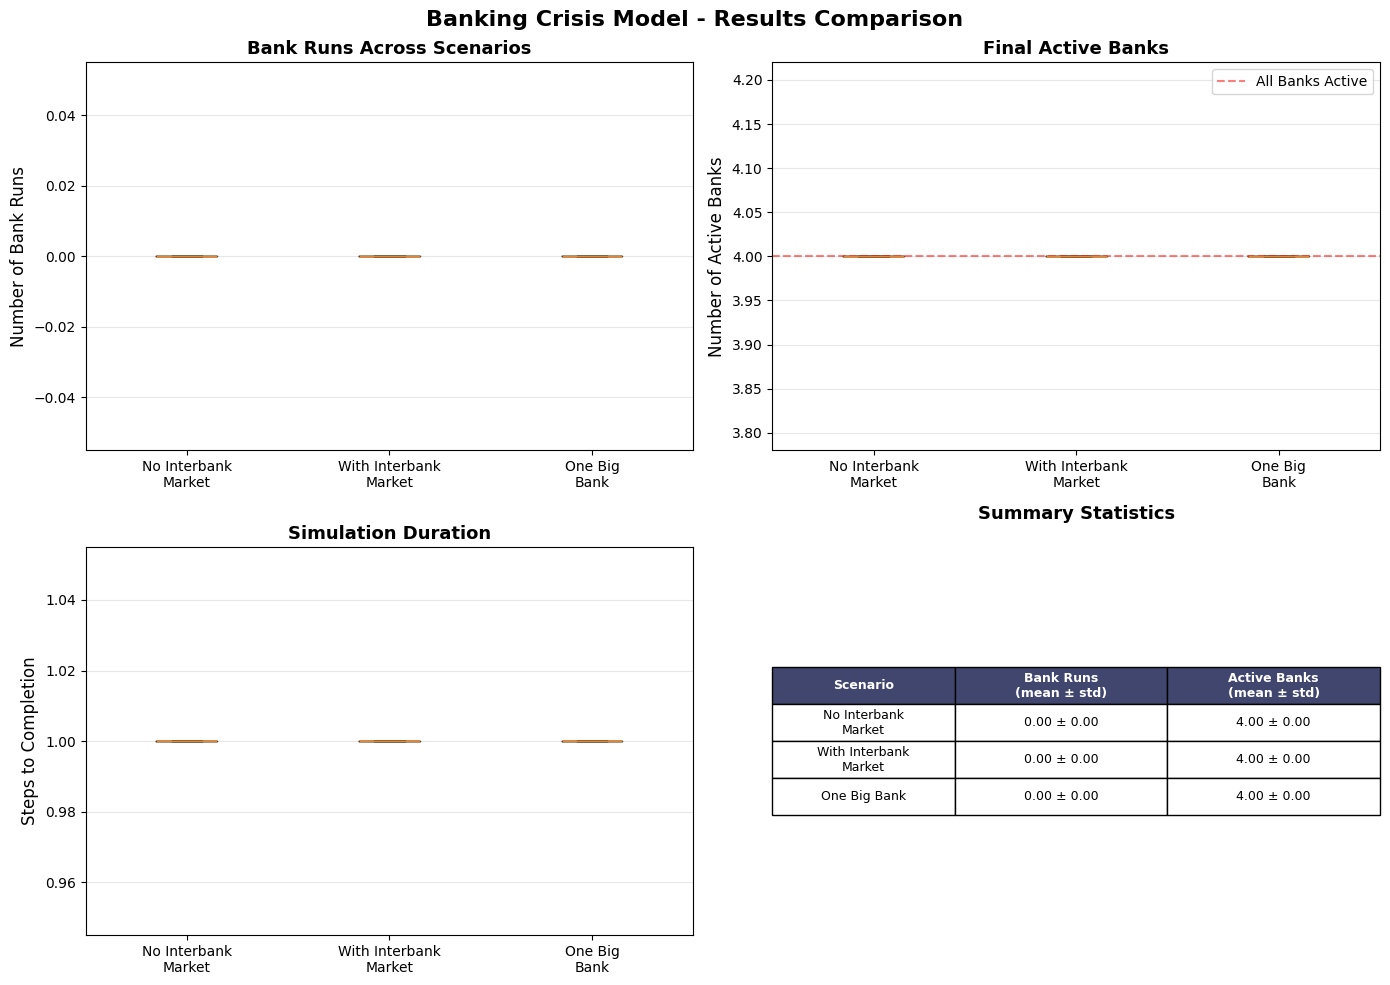


✓ Visualization complete


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Banking Crisis Model - Results Comparison', fontsize=16, fontweight='bold')

# Plot 1: Bank Runs Distribution
ax = axes[0, 0]
data_to_plot = [
    results_no_interbank['bank_runs'],
    results_with_interbank['bank_runs'],
    results_big_bank['bank_runs']
]
bp = ax.boxplot(data_to_plot, labels=['No Interbank\nMarket', 'With Interbank\nMarket', 'One Big\nBank'])
ax.set_ylabel('Number of Bank Runs', fontsize=12)
ax.set_title('Bank Runs Across Scenarios', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Active Banks at End
ax = axes[0, 1]
data_to_plot = [
    results_no_interbank['final_active_banks'],
    results_with_interbank['final_active_banks'],
    results_big_bank['final_active_banks']
]
bp = ax.boxplot(data_to_plot, labels=['No Interbank\nMarket', 'With Interbank\nMarket', 'One Big\nBank'])
ax.set_ylabel('Number of Active Banks', fontsize=12)
ax.set_title('Final Active Banks', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=4, color='r', linestyle='--', alpha=0.5, label='All Banks Active')
ax.legend()

# Plot 3: Steps to Completion
ax = axes[1, 0]
data_to_plot = [
    results_no_interbank['steps'],
    results_with_interbank['steps'],
    results_big_bank['steps']
]
bp = ax.boxplot(data_to_plot, labels=['No Interbank\nMarket', 'With Interbank\nMarket', 'One Big\nBank'])
ax.set_ylabel('Steps to Completion', fontsize=12)
ax.set_title('Simulation Duration', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 4: Summary Statistics Table
ax = axes[1, 1]
ax.axis('tight')
ax.axis('off')

summary_data = [
    ['Scenario', 'Bank Runs\n(mean ± std)', 'Active Banks\n(mean ± std)'],
    ['No Interbank\nMarket',
     f"{results_no_interbank['bank_runs'].mean():.2f} ± {results_no_interbank['bank_runs'].std():.2f}",
     f"{results_no_interbank['final_active_banks'].mean():.2f} ± {results_no_interbank['final_active_banks'].std():.2f}"],
    ['With Interbank\nMarket',
     f"{results_with_interbank['bank_runs'].mean():.2f} ± {results_with_interbank['bank_runs'].std():.2f}",
     f"{results_with_interbank['final_active_banks'].mean():.2f} ± {results_with_interbank['final_active_banks'].std():.2f}"],
    ['One Big Bank',
     f"{results_big_bank['bank_runs'].mean():.2f} ± {results_big_bank['bank_runs'].std():.2f}",
     f"{results_big_bank['final_active_banks'].mean():.2f} ± {results_big_bank['final_active_banks'].std():.2f}"]
]

table = ax.table(cellText=summary_data, cellLoc='center', loc='center',
                colWidths=[0.3, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style the header row
for i in range(3):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")



DETAILED SINGLE RUN EXAMPLE

Initial Setup:
  Number of banks: 4
  Customers per bank: 10
  Total customers: 40
  Impatient probability: 0.5
  Interbank market: False

Final Results:
  Total steps: 1
  Bank runs: 0
  Final active banks: 4


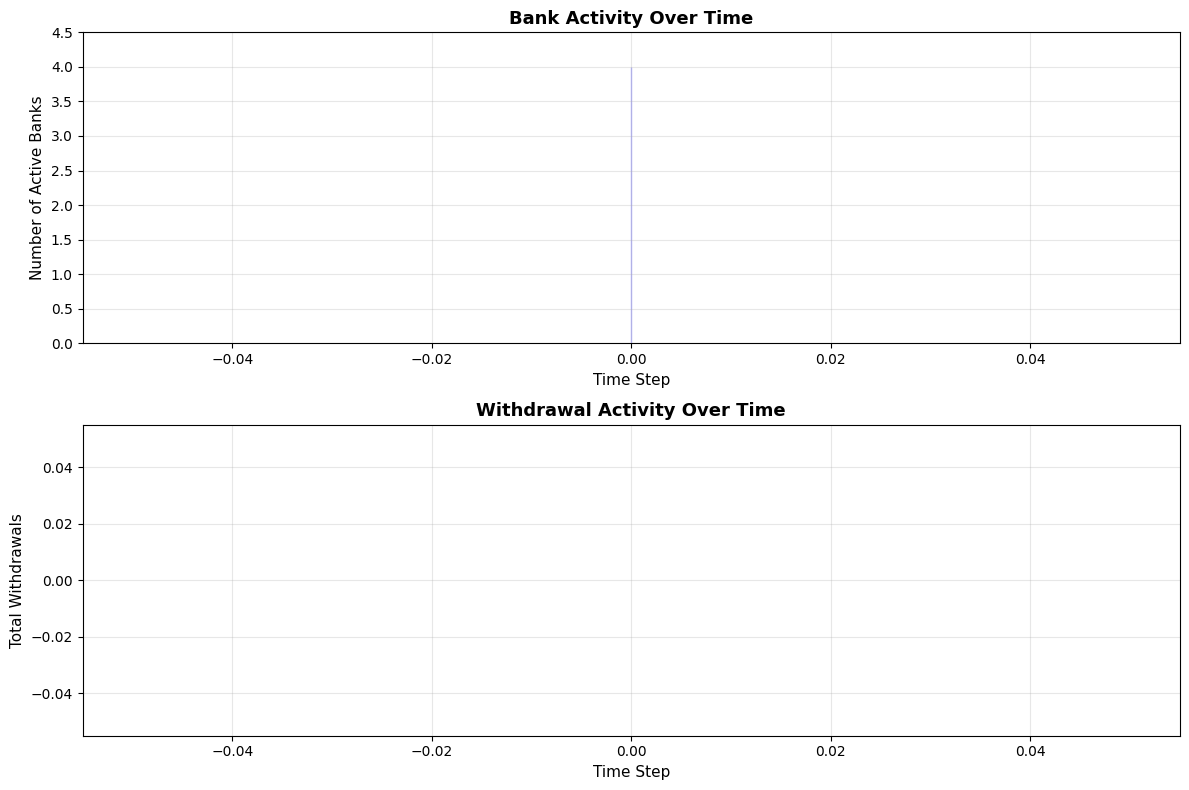


✓ Detailed analysis complete


In [9]:
print("\n" + "="*70)
print("DETAILED SINGLE RUN EXAMPLE")
print("="*70)

model = BankingModel(
    num_banks=4,
    customers_per_bank=10,
    impatient_probability=0.5,
    interbank_market=False,
    one_big_bank=False,
    seed=42
)

print(f"\nInitial Setup:")
print(f"  Number of banks: {model.num_banks}")
print(f"  Customers per bank: 10")
print(f"  Total customers: {len(model.customers)}")
print(f"  Impatient probability: {model.impatient_probability}")
print(f"  Interbank market: {model.interbank_market}")

# Run simulation
step_count = 0
while model.running and step_count < 50:
    model.step()
    step_count += 1

    if step_count % 10 == 0:
        active_banks = sum(1 for b in model.banks.values() if b.active)
        failed_banks = sum(1 for b in model.banks.values() if b.failed)
        print(f"  Step {step_count}: Active banks = {active_banks}, Failed banks = {failed_banks}")

# Get results
model_data = model.datacollector.get_model_vars_dataframe()

print(f"\nFinal Results:")
print(f"  Total steps: {model.steps}")
print(f"  Bank runs: {model_data['Bank Runs'].iloc[-1]}")
print(f"  Final active banks: {model_data['Active Banks'].iloc[-1]}")

# Plot time series
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot active banks over time
ax = axes[0]
ax.plot(model_data.index, model_data['Active Banks'], linewidth=2, color='blue')
ax.fill_between(model_data.index, 0, model_data['Active Banks'], alpha=0.3, color='blue')
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Number of Active Banks', fontsize=11)
ax.set_title('Bank Activity Over Time', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 4.5)

# Plot total withdrawals over time
ax = axes[1]
ax.plot(model_data.index, model_data['Total Withdrawals'], linewidth=2, color='red')
ax.fill_between(model_data.index, 0, model_data['Total Withdrawals'], alpha=0.3, color='red')
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Total Withdrawals', fontsize=11)
ax.set_title('Withdrawal Activity Over Time', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Detailed analysis complete")

In [10]:
all_results = pd.concat([
    results_no_interbank.assign(scenario='No Interbank Market'),
    results_with_interbank.assign(scenario='With Interbank Market'),
    results_big_bank.assign(scenario='One Big Bank')
], ignore_index=True)

# Display summary
print("\n" + "="*70)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*70)
summary = all_results.groupby('scenario').agg({
    'bank_runs': ['mean', 'std', 'min', 'max'],
    'final_active_banks': ['mean', 'std', 'min', 'max'],
    'steps': ['mean', 'std', 'min', 'max']
}).round(2)

print("\n", summary)

# Save to CSV (optional - uncomment to save)
# all_results.to_csv('banking_model_results.csv', index=False)
# print("\n✓ Results saved to 'banking_model_results.csv'")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)



COMPREHENSIVE RESULTS SUMMARY

                       bank_runs              final_active_banks               \
                           mean  std min max               mean  std min max   
scenario                                                                       
No Interbank Market         0.0  0.0   0   0                4.0  0.0   4   4   
One Big Bank                0.0  0.0   0   0                4.0  0.0   4   4   
With Interbank Market       0.0  0.0   0   0                4.0  0.0   4   4   

                      steps               
                       mean  std min max  
scenario                                  
No Interbank Market     1.0  0.0   1   1  
One Big Bank            1.0  0.0   1   1  
With Interbank Market   1.0  0.0   1   1  

ANALYSIS COMPLETE!
